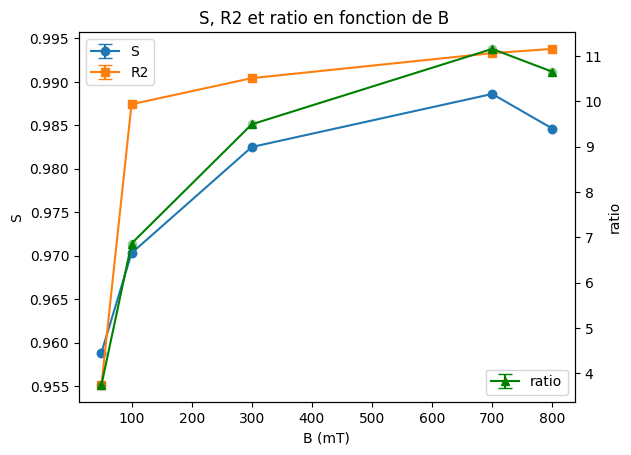

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1. Charger le CSV ===
# adapte le nom du fichier ici

df = pd.read_csv("T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_align_fev26/20250369/2026/Run1/lacroix/s0016/analysis_results_batch.csv", sep=",")  # ou sep="," selon ton fichier

# === 2. Nettoyage ===
# garder seulement les lignes valides
df = df[df["status"] == "success"]
#df = df[df["B (mT)"] != 300.0]
#df = df[df["B (mT)"] != 5.0]
#df = df[df["B (mT)"] != 0.0]
#df = df[df["B (mT)"] != 50.0]
# convertir en float
cols = ["B (mT)", "nematic_parameter", "R2", "ratio"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=cols)

# === 3. Regroupement par B ===
grouped = df.groupby("B (mT)")

# moyenne
mean = grouped.mean(numeric_only=True)

# écart-type
std = grouped.std(numeric_only=True)

# === 4. Plot ===
fig, ax1 = plt.subplots()

B = mean.index

# --- S (nematic_parameter) ---
ax1.errorbar(B, mean["nematic_parameter"],
             yerr=std["nematic_parameter"],
             fmt='o-', label="S", capsize=5)

# --- R2 ---
ax1.errorbar(B, mean["R2"],
             yerr=std["R2"],
             fmt='s-', label="R2", capsize=5)

ax1.set_xlabel("B (mT)")
ax1.set_ylabel("S")
ax1.legend(loc="upper left")

# --- ratio sur axe secondaire ---
ax2 = ax1.twinx()

ax2.errorbar(B, mean["ratio"],
             yerr=std["ratio"],
             fmt='^-', color='green',
             label="ratio", capsize=5)

ax2.set_ylabel("ratio")
ax2.legend(loc="lower right")
# === 5. Ajouter les points individuels ===
for b_val, group in grouped:
    ax1.scatter([b_val]*len(group), group["nematic_parameter"], color='blue', alpha=0.3)
    #ax1.scatter([b_val]*len(group), group["R2"], color='orange', alpha=0.3)
    ax2.scatter([b_val]*len(group), group["ratio"], color='green', alpha=0.3)

# === 6. Affichage ===
plt.title("S, R2 et ratio en fonction de B ")
plt.show()